# **Урок 11. OCR**

В теоретической части мы с вами познакомились с задачей распознавания символов - OCR, и выяснили, что как правило она включает в себя три части: детекцию текста, распознавание текста и извлечение из текста значимой информации. 

Все части пайплайна весьма интересны, но давайте сегодня сконцентрируемся на средней его части - методах непосредственного распознавания текста. Как мы выяснили, в этих методах не пытаются проклассифицировать по словарю каждое слово или задетектировать и распознать каждый символ отдельно, а распознают последовательности - либо по словам, либо целыми фразами. 

Давайте разебрем сегодня ключевой метод в `OCR` - архитектуру `CRNN`. И попробуем применить его к довольно неожиданной задаче - распознаванию штрихкодов. 

## **План**
1. Разбираемся с данными.
2. Создаём свою `CRNN`.
3. Обучаем модель.

Приступим!

## **1. Разбираемся с данными.**

In [1]:
import os
import cv2
import torch
import random
import torchvision

import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

import torchvision.models as models
import torchvision.datasets as datasets

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.nn.functional import log_softmax, ctc_loss
from torchvision.transforms.v2 import Resize, ToDtype, ToImage, Normalize, Compose

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Позаботимся о воспроизводимости 
def enable_determinism():
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)

def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)


enable_determinism()
fix_seeds(24)

In [3]:
PATH_TO_DATA = '/kaggle/input/datasets/andreykurdyubov/cv-lesson-11-barcodes/dataset/'

images_path = os.path.join(PATH_TO_DATA, 'images/')
assert os.path.isdir(images_path)

df_ann = pd.read_csv(PATH_TO_DATA + 'df_ann.csv', dtype='str')

df_ann.head()

,imname,code
0,0008080025111.jpg,0008080025111
1,0010900005043.jpg,0010900005043
2,0010900013314.jpg,0010900013314
3,0010900080316.jpg,0010900080316
4,0011110414380.jpg,0011110414380


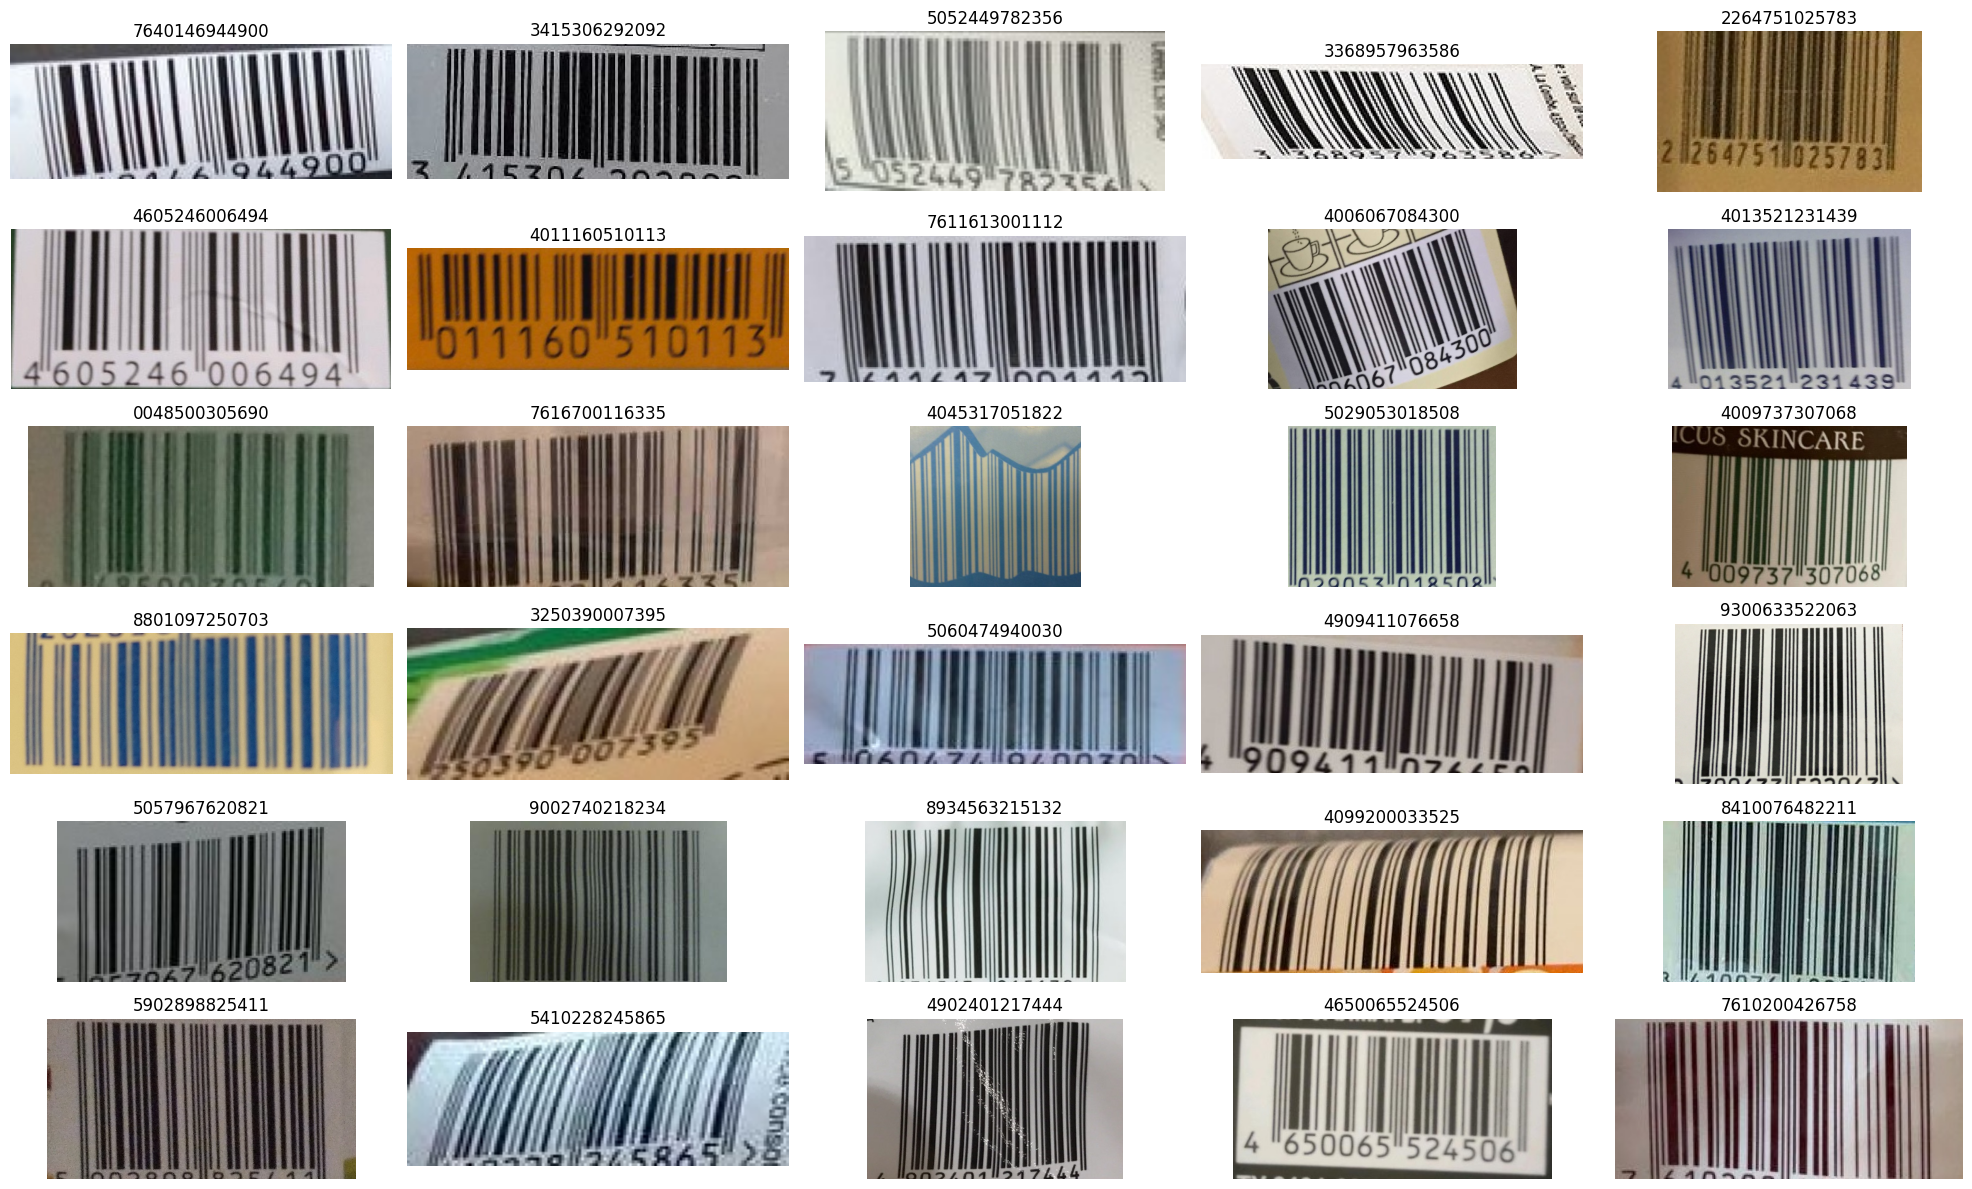

In [4]:
SAMPLE_SIZE = 30
NUM_COLS = 5
NUM_ROWS = SAMPLE_SIZE // NUM_COLS + int(SAMPLE_SIZE % NUM_COLS != 0)

random_idxs = np.random.choice(len(df_ann), size=SAMPLE_SIZE, replace=False)
plt.figure(figsize=(20, 2 * NUM_ROWS))
for i, idx in enumerate(random_idxs, 1):
    item = df_ann.loc[idx]
    text = item['code']
    image = cv2.imread(images_path + item['imname'])

    plt.subplot(NUM_ROWS, NUM_COLS, i)
    plt.imshow(image[:, :, ::-1])
    plt.title(text)
    plt.axis('off')
    

plt.tight_layout()
plt.show()

Как мы видим, очень много где цифры не просматриваются, значит сети придется научиться декодировать цифры из самих штрихов. Будет очень интересно посмотреть, сможет ли она разобраться как утроены штрихкоды. 

Но прежде чем сеть учить в них разбираться, давайте сами разберёмся. 

Системы кодов бывают самые разные, мы посмотрим на [`Code-128`](https://en.wikipedia.org/wiki/Code_128).

<img src="/kaggle/input/datasets/andreykurdyubov/cv-lesson11-ocr-asset/assets/code_zones.jpeg" style="height:300px">

    1,6 — Пустое место, нужное для четкого определения начала и конца кода.
    2 — Стартовый символ. Для Code-128 возможны 3 варианта (называемых А, В и С): 11010000100, 11010010000 или 11010011100, им соответствуют разные кодовые таблицы.
    3 — Сам код, содержащий нужные нам данные.
    4 — Контрольная сумма, необходимая для проверки правильности декодирования 3.
    5 — Стоп символ. Для Code-128 это 1100011101011.

Под штрихкодом обычно также есть человекочитаемая расшифровка кода. У него тоже есть разные системы записи.

<img src="assets/codes.png" style="height:400px">

А как же эти цифры (вернее их табличное представление) кодируются?


Тут все очень просто — если взять ширину самой тонкой линии за `1`, то линия двойной ширины даст код `11`, тройная `111`, и так далее. 

Пустое место будет `0` или `00` или `000` по тому же самому принципу.

Вот это, а также куда смотреть на штрихкодах, нашей сети и предстоит понять :)

А вот очень интересная [статья с Хабра](https://habr.com/ru/articles/439604/) про устройство штрихкодов с написанием простейшего алгоритма его декодирования. 

С утройством штрихкодов познакомились, теперь переходим к созданию класса датасета. Что важно:

- Для обучения нам потребуется возвращать в методе `__getitem__`:
  - Изображение в виде тензора (фиксированного размера `3xHxW`);
  - Изображение оригинальное для последуюшей визуализации (это удобно);
  - Текст кода в виде строки (это удобно);
  - Текст кода в виде числовой последовательности (т.е. в закодированном виде)'
  - Длину этой последовательности (требование для обучения с `CTC Loss`).
  
Удобно сложить все эти переменные в словарь и доставать их оттуда по ключам при необходимости.

Наши `gt` коды надо превратить в закондированные последовательности - просто каждому числу поставим в соответствие индекс в алфавите, а `0`-м сиволом будет `blank`. 

Например, пусть наш алфавит = `XYZ`. Тогда текст `XXZY` с учетом `blank` станет `[1,1,3,2]`.

У нас очень удачный алфавит, состоящий только из цифр, но мы сделаем для него полноценную обработку, которую вы сможете юзать и для более широких алфавитов.

In [5]:
alphabet = '0123456789'

In [6]:
class RecognitionDataset(Dataset):
    def __init__(self, df, root, alphabet=alphabet, transforms=None):
        super(RecognitionDataset, self).__init__()
        self.df = df
        self.root = root
        self.alphabet = alphabet
        self.image_names, self.texts = self._parse_root_()
        self.transforms = transforms

    def _parse_root_(self):
        image_names, texts = [], []
        for _, item in self.df.iterrows():
            image_name = os.path.join(self.root, item['imname'])
            text = str(item['code'])
            texts.append(text)
            image_names.append(image_name)
        return image_names, texts

    # Вот тут для символа возвращаем его индекс в алфавите
    def _text_to_seq_(self, text):
        seq = [self.alphabet.find(c) + 1 for c in text]
        return seq

    def __getitem__(self, item):
        pil_image = Image.open(self.image_names[item])
        torch_image = self.transforms(pil_image)
        text = self.texts[item] 
        seq  = self._text_to_seq_(text)
        seq_len = len(seq)
        
        output  = dict(torch_image=torch_image, pil_image=pil_image, seq=seq, seq_len=seq_len, text=text)
        return output

    def __len__(self):
        return len(self.texts)

In [7]:
transforms = Compose([
    ToImage(), 
    ToDtype(torch.float32, scale=True), 
    Resize(size=(64, 224)), # соотношение сторон 1:4
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = RecognitionDataset(df_ann, images_path, alphabet=alphabet, transforms=transforms)

In [8]:
x = dataset[0]
print(x.keys())

dict_keys(['torch_image', 'pil_image', 'seq', 'seq_len', 'text'])


In [9]:
print('Image shape:', x['torch_image'].shape)
print('Seq:' , x['seq'], 'Seq_len:', x['seq_len'])
print('Text:', x['text'])

Image shape: torch.Size([3, 64, 224])
Seq: [1, 1, 1, 9, 1, 9, 1, 1, 3, 6, 2, 2, 2] Seq_len: 13
Text: 0008080025111


Давайте поделим наш датафрейм на трейн и тест части, но сделаем это осмысленно - они должны поделиться не по изображениям, а по уникальным кодам.

In [10]:
unique_codes = sorted(np.unique(df_ann['code']))

print(len(unique_codes))
print(len(df_ann))

3508
3601


In [11]:
codes_for_train = random.sample(unique_codes, int(len(unique_codes) * 0.9)) 
codes_for_test = list(set(unique_codes) - set(codes_for_train))

In [12]:
df_train = df_ann[df_ann['code'].isin(codes_for_train)]
df_test = df_ann[df_ann['code'].isin(codes_for_test)]

In [13]:
df_train.reset_index(inplace=True, drop=True)
df_test.reset_index(inplace=True, drop=True)

In [14]:
train_dataset = RecognitionDataset(df_train, images_path, transforms=transforms)
test_dataset = RecognitionDataset(df_test, images_path, transforms=transforms)

Все наши коды имеют длину 13 - в этом нам очень повезло.

Но `Dataset` возвращает необычный для `Dataloader` формат, поэтому надо написать собственную `collate_fn`, чтобы он понял, как объединять эти объекты в батчи. 

In [15]:
seqs = [1, 2, 3, 1, 2, 3, 1, 1, 1, 1]
torch.Tensor(seqs).int()

tensor([1, 2, 3, 1, 2, 3, 1, 1, 1, 1], dtype=torch.int32)

In [16]:
def collate_fn(batch):
    torch_images, pil_images, seqs, seq_lens, texts = [], [], [], [], []
    
    for item in batch:
        torch_images.append(item['torch_image'])
        pil_images.append(item['pil_image'])
        seqs.extend(item['seq'])
        seq_lens.append(item['seq_len']) # собрали список из последовательностей
        texts.append(item['text'])
        
    torch_images = torch.stack(torch_images)
    pil_images   = pil_images
    seqs         = torch.Tensor(seqs).int() # стекнули последовательности вместе, CTC Loss потом разберется благодаря seq_lens
    seq_lens     = torch.Tensor(seq_lens).int()

    return {'torch_images': torch_images, 'pil_images':pil_images, 'seq': seqs, 'seq_len': seq_lens, 'text': texts}

In [17]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, drop_last=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=collate_fn)

In [18]:
for x in train_dataloader:
    print(x['torch_images'].shape)
    print(x['seq'].shape)
    print(x['seq_len'])
    break

torch.Size([32, 3, 64, 224])
torch.Size([416])
tensor([13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
        13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
       dtype=torch.int32)


Итак, мы 

- познакомились с утройством штрихкодов;
- создали `Dalaset`, который в `__getitem__` отдаёт нам кучу полезной информации, в том числе закодированные текстовые последовательности и их длины, необходимые для `CTC Loss`-а;
- написали кастомную `collate_fn`, которая эту кучу объединяет в понятный батч, а также стакает все текстовые последовательноcти в одну.

Прекрасно, с данными мы разобрались, на очереди нейронная сеть. 

## **2. Создаём свою CRNN.**

<img src="assets/crnn.png" style="height:700px">

Модель `CRNN` предназначена для перевода изображений в текстовый вид. Она устроена следующим образом:
1. Первый этап - извлечение признаков с помощью `CNN`. Входное изображение пропускается через последовательность свёрточных слоев (с активациями, пулингом, вот эти вот всем), в результате чего получается тензор признаков размера `C x H x W`. Если рассматривать в отдельности каждый из срезов вдоль оси "ширины", то можно сказать, что у нас получилась последовательность длины `W`. Каждый из этих элементов соответствует определенной области на исходном изображении:

<img src="assets/receptive.png" style="height:300px">

2. Второй этап - предсказание вероятностей каждого из символов алфавита **для каждого элемента последовательности** c помощью `RNN`. Полученная на первом шаге последовательность признаков пропускается через рекуррентную сеть, в результате чего на выходе образуется последовательность той же длины, что и на входе. Размер каждого элемента равен мощности алфавита +1 (этот "+1" - символ `blank`).
3. Третий этап - либо декодирование (или транскрипция) полученных на предыдущем шаге распределений в итоговый текст (при инференсе), либо вычисление `CTC-Loss-а` между полученными распределениями и `gt`-последовательностями (при обучении).


Начнем с построения `CNN` - или нашего энкодера. 

Для этого возьмем предобученную модель `ResNet50`, отрежем от нее последние два слоя (это `AdaptiveAvgPool2d` и `Linear`), оставив свёрточную часть. После всех свёрточных слоев размер входного изображения уменьшается в `32` раза, а значит, входная картинка размером `64x224` превратится в тензор размера `2x7`. Для него мы сделаем пулинг по высоте, превратив его в тензор размера `1x7`. 

Но тогда длина последовательности для подачи в `RNN` составит всего лишь `7` - этого, конечно, мало для предсказания предследовательностей длины 13. Используем трюк (в методе `apply_projection`), применив свёрточный слой с ядром `1x1` вдоль размерности ширины (а не глубины, как обычно), увеличив длину последовательности с `7` до `output_len`.

In [19]:
resnet = getattr(models, 'resnet50')(pretrained=True)
resnet?

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s] 


Signature:       resnet(*args, **kwargs)
Type:            ResNet
String form:    
ResNet(
           (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
           <...> iveAvgPool2d(output_size=(1, 1))
           (fc): Linear(in_features=2048, out_features=1000, bias=True)
           )
File:            /usr/local/lib/python3.12/dist-packages/torchvision/models/resnet.py
Docstring:       <no docstring>
Class docstring:
Base class for all neural network modules.

Your models should also subclass this class.

Modules can also contain other Modules, allowing them to be nested in
a tree structure. You can assign the submodules as regular attributes::

    import torch.nn as nn
    import torch.nn.functional as F


    class Model(nn.Module):
        def __init__(self) -> None:
            super().__init__()
            self.conv1 = nn.Conv2d(1, 20, 5)
            self.conv2 = nn.Conv2d(20, 20, 5)

        def forward(self, x):
            x = F.relu(self.c

In [20]:
class Encoder(nn.Module):
    def __init__(self, input_size=(64, 224), output_len=28):
        super(Encoder, self).__init__()
        h, w = input_size
        resnet = getattr(models, 'resnet50')(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        self.pool = nn.AvgPool2d(kernel_size=(h // 32, 1))   # сделали пулинг по высоте и получили 1x7xC    
        self.proj = nn.Conv2d(w // 32, output_len, kernel_size=1) # с помощью проекции получим 1 x output_len x C
  
        self.num_output_features = self.cnn[-1][-1].bn3.num_features    

    
    def apply_projection(self, x):
        x = x.permute(0, 3, 2, 1).contiguous() # Поменяли размерности, чтобы применить self.proj
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1).contiguous() # Вернули размерности на место
        
        return x
   
    def forward(self, x):
        features = self.cnn(x) # Получили фичи
        features = self.pool(features) # Спулили высоту к 1
        features = self.apply_projection(features) # Спроецировали ширину к output_len

        return features

In [21]:
feature_extractor = Encoder()

In [22]:
x = torch.randn(1, 3, 64, 224)
y = feature_extractor(x)
print(y.size())

torch.Size([1, 1, 2048, 28])


Итого, `Encoder`:
- На вход получает тензор изображения размером `Bx3xHxW`
- На выходе отдает тензор признаков размером `Bx1xFxL`, где 
  - `F` - размерность вектора-токена (определяется числом признаков последнего сверточного слоя `ResNet50`, т.е. 2048), 
  - `L` - длина последовательности токенов, равная `self.output_len`.

На очереди часть `RNN` - или декодер сети.

Будем использовать `GRU` (`bidirectional` как опция). Результат предсказаний после `GRU` дополнительно отправим в линейный слой для формирования итоговой матрицы с `logits`, определяемой длиной алфавита.

Про размерность `hidden_state` можно [почитать в документации](https://pytorch.org/docs/stable/nn.html?highlight=gru#torch.nn.GRU).

`GRU` по умолчанию ожидает на вход тензор размера `L x B x F`, где `L` - длина последовательности, `B` - размер батча, `F` - размер одного элемента последовательности, поэтому выходы `CNN` надо будет переформировать.  

In [23]:
class Decoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3, bidirectional=False):
        super(Decoder, self).__init__()
        
        self.num_classes = num_classes        
        self.rnn = nn.GRU(input_size=input_size,
                       hidden_size=hidden_size,
                       num_layers=num_layers,
                       dropout=dropout,
                       bidirectional=bidirectional)
        
        fc_in = hidden_size if not bidirectional else 2 * hidden_size
        self.fc = nn.Linear(in_features=fc_in,
                         out_features=num_classes)

    # Инициализирует тензор из нулей размера (num_layers * num_directions, batch, hidden_size) для hidden state RNN
    def _init_hidden(self, batch_size):
        num_directions = 2 if self.rnn.bidirectional else 1
        
        h = torch.zeros(self.rnn.num_layers * num_directions, batch_size, self.rnn.hidden_size)
        return h

    # Решейпим тензор из CNN (B x (C=1) x H x W) -> (W(L) x B x H(F))
    def _reshape_features(self, x):
        x = x.squeeze(1)
        x = x.permute(2, 0, 1)
        return x
    
    def forward(self, x):
        x = self._reshape_features(x)

        batch_size = x.size(1)
        h_0 = self._init_hidden(batch_size)
        h_0 = h_0.to(x.device)
        
        x, h = self.rnn(x, h_0)
        x = self.fc(x)
        return x

In [24]:
decoder = Decoder(input_size=2048, 
                    hidden_size=256, 
                    num_layers=2, 
                    num_classes=len(alphabet) + 1)

In [25]:
x = torch.randn(1, 1, 2048, 28)
assert decoder._reshape_features(x).size() == (28, 1, 2048)

In [26]:
y = decoder(x)
print(y.shape)

torch.Size([28, 1, 11])


Теперь соберем две части в один класс CRNN.

In [27]:
class CRNN(nn.Module):
    def __init__(self, alphabet=alphabet,
                 cnn_input_size=(64, 224), cnn_output_len=28,
                 rnn_hidden_size=256, rnn_num_layers=2, 
                 rnn_dropout=0.3, rnn_bidirectional=False):
        super(CRNN, self).__init__()
        self.alphabet = alphabet
        self.encoder = Encoder(input_size=cnn_input_size, output_len=cnn_output_len)
        self.decoder = Decoder(input_size=self.encoder.num_output_features,
                               hidden_size=rnn_hidden_size, num_layers=rnn_num_layers,
                               num_classes=len(alphabet)+1, dropout=rnn_dropout,
                               bidirectional=rnn_bidirectional)
    
    def forward(self, x):
        features = self.encoder(x)
        sequence = self.decoder(features)
        return sequence

In [28]:
crnn = CRNN()

In [29]:
x = torch.randn(1, 3, 64, 224)
y = crnn(x)
print(y.size())

torch.Size([28, 1, 11])


Отлично, мы получили выходной тензор с вероятностями символов. Осталось его декодировать.

1. Решаемая задача имеет особенность: количество `временных шагов` фиксировано.
2. Число `временных шагов` (а значит и нарезку нашего изображение на receptive fields) можно менять за счёт настройки свёрточных слоёв.
3. В некоторых ситуациях возникает удваивание символов: два одинаковых символа стоят рядом либо символ попадает в два соседних `временных шага`. Чтобы разделять эти ситуации мы и используем вспомогательный `пустой символ`.

<img src="...
" width=750 />

Правила декодирования текста:
- Удаляем всё дублирующиеся символы;
- Удаляем оставшиеся пустые символы.

$$
\begin{array}{ll}
---TTTOOO-, & или & T--OOOO--- & → & TO \\
-TTT--OO-O, & или & TOO--O---- & → & TOO
\end{array}
$$

In [30]:
# Тензор предсказаний декодируем в строку
def pred_to_string(pred, abc):
    # Для каждого выхода получаем наиболее вероятный символ
    seq = []
    for i in range(len(pred)):
        label = np.argmax(pred[i])
        seq.append(label - 1)

    # Дальше убираем пустые символы и дубли
    out = []
    for i in range(len(seq)):
        if len(out) == 0:
            if seq[i] != -1:
                out.append(seq[i])
        else:
            if seq[i] != -1 and seq[i] != seq[i - 1]:
                out.append(seq[i])
    out = ''.join([abc[c] for c in out])
    return out

# Функция декодирования батча предсказаний по алфавиту
def decode(pred, abc):
    pred = pred.permute(1, 0, 2).cpu().data.numpy()
    outputs = []
    for i in range(len(pred)):
        outputs.append(pred_to_string(pred[i], abc))
    return outputs

In [31]:
res = decode(y, alphabet)
print(len(res[0]))
print(res)

18
['584980949595905050']


Прекрасно, подведём итоги этого раздела. 

Итак, мы 

- написали `CNN` часть сети на основе `ResNet50`, из которой мы будем получать вектора признаков для "вертикальных слайсов" нашей текстовой строки;
- написали `RNN` часть сети на оснве `GRU`, которая по признакам из `CNN` будет вычислять `logit`-ы для выходной последовательности фиксированного размера;
- объединили их в `CRNN`;
- написали функцию для декодирования, которая на основе `logit`-ов вычисляет финальную последовательность.

Осталось это чудо обучить. 

## **3. Обучаем модель.**

Прежде чем обучать модель, давайте ещё раз вспомним про работу `CTC Loss-а`.


**Как вычисляется функция потерь.**

Результат работы модели

<img src="...
" width=750 />

В соотвествии с `ground-truth` разметкой (в данном случае у нас слово `door`) копируем данные в более компактное представление:

<img src="...
4nx26WQAAAAASUVORK5CYII=" width=750 />

Существует экспоненциально большое количество `правильных` путей

<img src="..." width=750 />

<img src="...
SUVORK5CYII=" width=750 />


$score(pathA)=y(0,0)∗y(0,1)∗y(0,2)∗y(1,3)∗y(1,4)∗y(2,5)∗y(3,6)∗y(4,7)∗y(5,8)∗y(7,9)$

$score(pathB)=y(1,0)∗y(1,1)∗y(2,2)∗y(3,3)∗y(3,4)∗y(4,5)∗y(5,6)∗y(7,7)∗y(7,8)∗y(8,9)$

Сумма вероятностей всех будет и будет значением `CTC Loss-a.`

Класс этой функции потерь уже реализован в `PyTorch`, поэтому нам нужно только понять, как правильно подать в него предсказания и `ground-truth`-метки. 


Как это нужно делать как всегда узнаём из [документации](https://pytorch.org/docs/stable/generated/torch.nn.functional.ctc_loss.html#torch.nn.functional.ctc_loss)

На что следует обратить внимание:
* Функция ожидает на вход не только пару предсказанных и верных последовательностей, но и информацию о длинах этих последовательностей.
* Перед тем, как подавать предсказания в лосс, необходимо применить к ним активацию `softmax` и взять логарифм.

Теперь у нас всё готово для того, чтобы обучить модель. 

In [33]:
crnn = CRNN()
_ = crnn.to(device)

optimizer = torch.optim.Adam(crnn.parameters(), lr=1e-3, amsgrad=True, weight_decay=1e-4)

In [34]:
num_epochs = 20
batch_size = 128
num_workers = 12

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, collate_fn=collate_fn)

In [35]:
crnn.train()
for i, epoch in enumerate(range(num_epochs)):
    epoch_losses = []

    for j, b in enumerate(tqdm(train_dataloader, total=len(train_dataloader))):
        images = b['torch_images'].to(device)
        seqs_gt = b['seq']
        seq_lens_gt = b['seq_len']

        seqs_pred = crnn(images).cpu()
        log_probs = log_softmax(seqs_pred, dim=2)
        seq_lens_pred = torch.Tensor([seqs_pred.size(0)] * seqs_pred.size(1)).int()

        loss = ctc_loss(log_probs=log_probs,  # (T, N, C)
                        targets=seqs_gt,  # N, S or sum(target_lengths)
                        input_lengths=seq_lens_pred,  # N
                        target_lengths=seq_lens_gt, # N
                        zero_infinity=True)  

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    print(f'Epoch {i+1}, Loss: {np.mean(epoch_losses)}')

100%|██████████| 25/25 [00:55<00:00,  2.21s/it]


Epoch 1, Loss: 2.424103841781616


100%|██████████| 25/25 [00:18<00:00,  1.35it/s]


Epoch 2, Loss: 2.164769296646118


100%|██████████| 25/25 [00:18<00:00,  1.37it/s]


...

Epoch 18, Loss: 0.2706194490194321


100%|██████████| 25/25 [00:19<00:00,  1.31it/s]


Epoch 19, Loss: 0.2462166166305542


100%|██████████| 25/25 [00:18<00:00,  1.36it/s]

Epoch 20, Loss: 0.22356040239334107


Провалидируем:

In [36]:
crnn.eval()
test_losses = []
for i, b in enumerate(tqdm(test_dataloader, total=len(test_dataloader))):
    images = b['torch_images'].to(device)
    seqs_gt = b['seq']
    seq_lens_gt = b['seq_len']

    with torch.no_grad():
        seqs_pred = crnn(images).cpu()
    log_probs = log_softmax(seqs_pred, dim=2)
    seq_lens_pred = torch.Tensor([seqs_pred.size(0)] * seqs_pred.size(1)).int()

    loss = ctc_loss(log_probs=log_probs,  
                    targets=seqs_gt, 
                    input_lengths=seq_lens_pred, 
                    target_lengths=seq_lens_gt)

    test_losses.append(loss.item())

print('Mean test loss: ', np.mean(test_losses))

100%|██████████| 3/3 [00:06<00:00,  2.03s/it]

Mean test loss:  0.8298616409301758


Лосс на тесте получается в несколько раз выше, чем на обучении. Интересно, а будут ли при этом уже адекватные предсказания получаться?

Возьмем последний батч из теста и посмотрим на предсказанные для него распределения и их декодированные последовательности.

In [37]:
# Прогоним батч через сеть
preds = crnn(b['torch_images'].to(device)).cpu().detach()
texts_pred = decode(preds, alphabet)

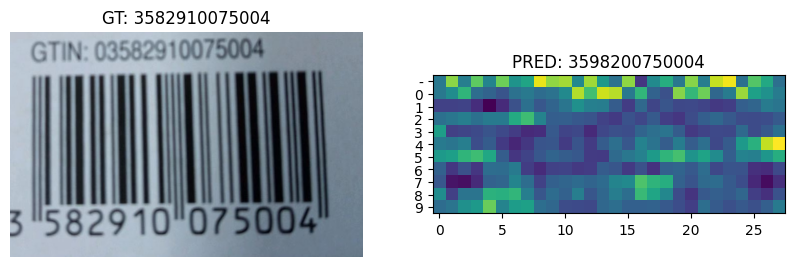

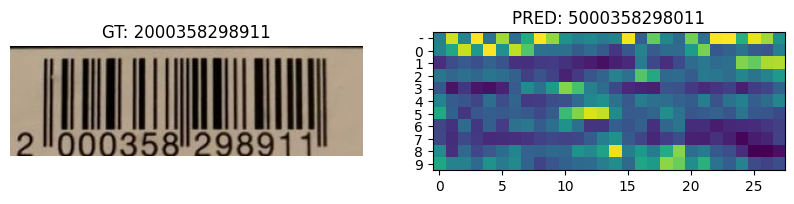

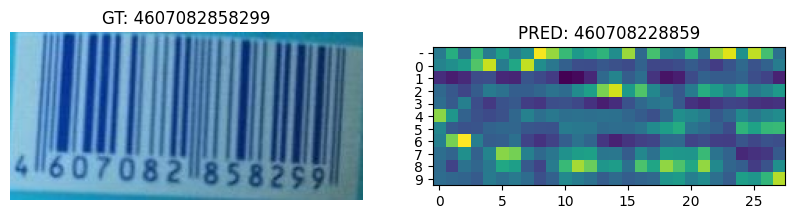

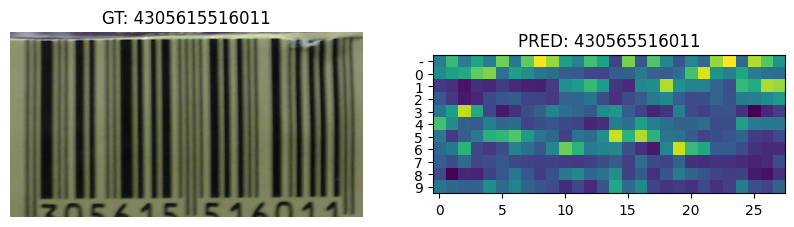

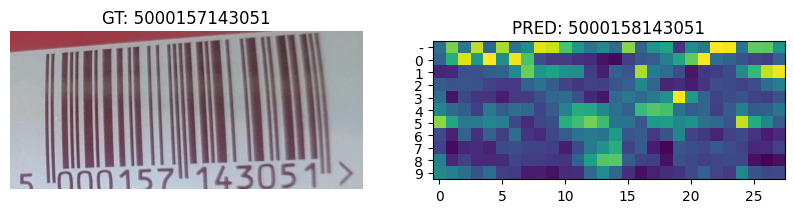

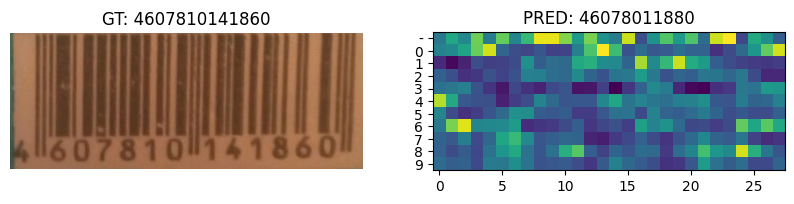

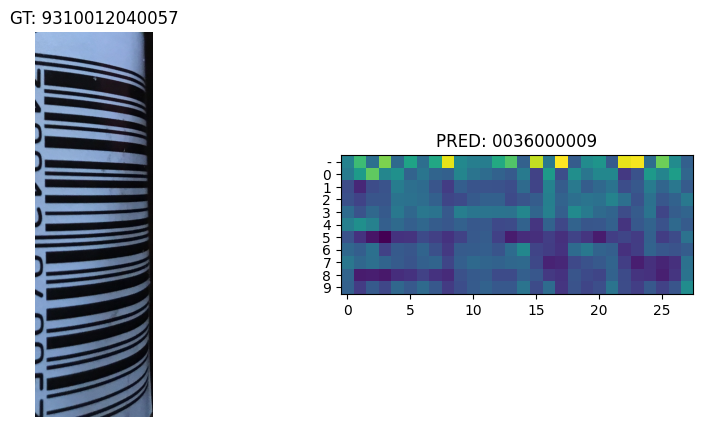

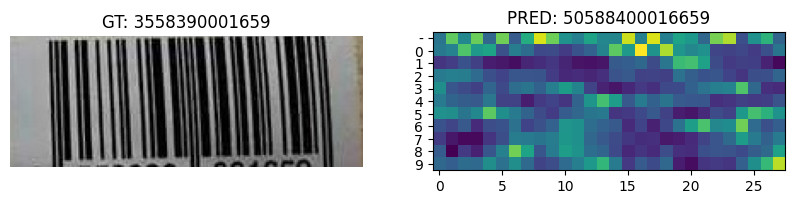

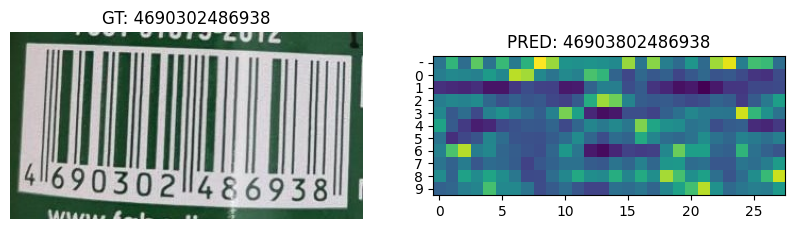

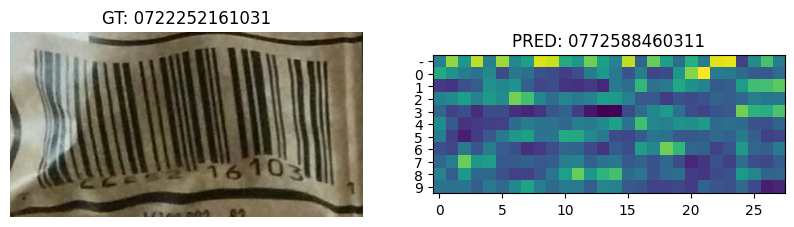

In [38]:
y_ticks = ['-'] + [x for x in alphabet]

for i in range(10):
    plt.figure(figsize=(10, 5))
    pred_i = preds[:, i, :].T

    plt.subplot(1, 2, 1)

    pil_image = b['pil_images'][i]
    plt.imshow(pil_image)
    plt.axis('off')
    plt.title(f"GT: {b['text'][i]}")

    plt.subplot(1, 2, 2)
    plt.yticks(range(pred_i.size(0)), y_ticks)
    plt.imshow(pred_i)
    plt.title(f'PRED: {texts_pred[i]}')

    plt.show()

Выглядит довольно круто, хоть и неидеально.

Очень явно можем отследить, какие шаги выходной последовательности за предсказания каких цифр отвечали. 

А заодно убедились, что даже там, где цифр вообще не видно, сеть по палочкам и их толщине вполне поняла, какая цифра была закодировала. 


Итак, мы 

- посмотрели как вычисляется `CTC Loss`;
- с его помощью смогли обучить написанную нами `CRNN`;
- посмотрели на качественные результаты работы модели;
- увидели, как в `logit`-ах модели явно прослеживаются символы будущи последовательностей.

Подведём финальные итоги.

## **Итоги**

В этой практике мы:

- узнали интересное про штрихкоды и написали для них `Dataset`;
- написали собственную `CRNN` на базе `ResNet50` и `GRU`;
- убедились в необходимости служебного `blank` символа;
- написали декодер для получаемых из сети последовательностей;
- ещё раз обсудили `CTC Loss` и посмотрели на процесс его вычисления;
- обучили сеть распознавать штрихкоды;
- посмотрели на качественные результаты её работы и остались очень довольны.

Ай да мы!

Можно было бы посчитать метрики и `levenstein distance`, но вам это ещё предстоит в ДЗ. 

See you!